# [1교시]

분류(Classification)의 핵심 알고리즘과 수식

In [2]:

from math import prod

classes = ["Spam", "Ham"]  # 클래스
prior = {"Spam": 0.4, "Ham": 0.6}  # 사전 확률 P(C)

# 단어별 우도 P(X|C)
likelihood = {
    "Spam": {"free": 0.7, "urgent": 0.6},
    "Ham": {"free": 0.2, "urgent": 0.1},
}
X = ["free", "urgent"]  # 예측하려는 텍스트의 단어들

scores = {}
for c in classes:
    px_given_c = prod([likelihood[c][token] for token in X])
    scores[c] = px_given_c * prior[c]

pred = max(scores, key=scores.get)
print("NB scores:", scores)
print("NB prediction:", pred)

NB scores: {'Spam': 0.168, 'Ham': 0.012000000000000002}
NB prediction: Spam


# [2교시]

In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
# 훈련 데이터
train_texts = ["free urgent offer", "free free urgent", "meeting schedule", "project discussion"]
labels = ['Spam', 'Spam','Harm','Harm']
# 테스트 -> 숫자
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_texts)
model = MultinomialNB()
model.fit(X_train,labels)
# 예측할 문장
test_text = ['i am free']
X_test =  vectorizer.transform(test_text)
pred = model.predict_proba(X_test)
pred , model.classes_

(array([[0.22807018, 0.77192982]]), array(['Harm', 'Spam'], dtype='<U4'))

In [4]:
print('class prior p(C)')
print(model.class_log_prior_)

print('feature log probality p(word|C)')
print(model.feature_log_prob_)

print('vocabulary')
print(vectorizer.get_feature_names_out())

class prior p(C)
[-0.69314718 -0.69314718]
feature log probality p(word|C)
[[-1.70474809 -2.39789527 -1.70474809 -2.39789527 -1.70474809 -1.70474809
  -2.39789527]
 [-2.56494936 -1.178655   -2.56494936 -1.87180218 -2.56494936 -2.56494936
  -1.46633707]]
vocabulary
['discussion' 'free' 'meeting' 'offer' 'project' 'schedule' 'urgent']


In [5]:
# iris를 가지고 품종 분류
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
nb = MultinomialNB()
nb.fit(x_train, y_train)
y_predict = nb.predict(x_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



# [3교시]

In [6]:
from collections import Counter
from math import sqrt
import numpy as np

train_X = np.array([[1, 1], [2, 1], [4, 4], [5, 4]])
train_y = np.array([0, 0, 1, 1])
query = [2, 2]
k = 3

def euclidean(p, q):
    #### [ 빈칸 : 이 부분을 직접 코딩하세요 ]
    # 목표: 텍스트 풀이에서 계산한 sqrt 를 코드로 재현
    return sqrt(sum((p-q)**2))

dists = [(euclidean(query, x), int(y)) for x,y in zip(train_X, train_y)]
def temp(data):
    return data[0]

dists.sort(key=lambda x : x[0])
# knn = [label for _, label in dists[:k]]
# Counter(knn)
pred = Counter(knn).most_common(1)[0][0]
# Counter:Dic형태로 만들어 개수를 세어줌 / value기준으로 내림차순 정렬 후 선택한 값이 2가 됨

print("k-NN sorted distances:", dists)
print("k-NN neighbors:", knn)
print("k-NN prediction:", pred)

NameError: name 'knn' is not defined

In [ ]:
from sklearn.neighbors import KNeighborsClassifier   # K-최근접 이웃(KNN) 분류기를 불러옴
from sklearn.datasets import load_iris               # 붓꽃(iris) 데이터셋을 불러오는 함수
from sklearn.model_selection import train_test_split # 학습용/테스트용 데이터 분할 함수
from sklearn.metrics import classification_report    # 분류 결과 평가 리포트 출력 함수

iris = load_iris(as_frame=True)   # 붓꽃 데이터셋을 DataFrame 형태로 불러오기
X = iris.data                     # 입력 데이터(꽃받침, 꽃잎의 길이와 너비)
y = iris.target                   # 타깃 데이터(품종: setosa, versicolor, virginica)

# 학습용과 테스트용 데이터로 분할 (stratify=y: 클래스 비율을 유지, random_state=42: 재현성 보장)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

kgc = KNeighborsClassifier(n_neighbors=20)  # KNN 분류기 생성, 이웃 수 k=20으로 설정
kgc.fit(X_train, y_train)                   # 학습용 데이터로 KNN 모델 학습
y_predict = kgc.predict(X_test)             # 테스트 데이터에 대해 예측 수행

print(classification_report(y_test, y_predict))  
# 실제 정답(y_test)과 예측값(y_predict)을 비교하여 정확도, 정밀도, 재현율, F1 점수 출력


# [4교시]

In [7]:
# 최적의 k 찾기
# k=1, 2, 3, ~~ N
# 각 k의 값에 따른 교차검증(cv=5)을 해서 (score, k) 리스트로 저장
# score가 가장 높을때의 k의 값을 출력

from sklearn.model_selection import cross_val_score
k_list = [1, 3, 5, 6, 7, 9, 10, 12, 15, 20, 30, 35, 40]
result = [(cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train).mean(), k)
    for k in k_list]

result.sort(key = lambda x : x[0], reverse=True )
besk_k = result[0][1]

NameError: name 'KNeighborsClassifier' is not defined

In [ ]:
# 선형회귀 : 공부 시간을 보고 시험 점수(연속값)를 예측
# 로지스틱 회귀 : 공부 시간 + 출석률을 보고 합격/불합격(0/1)을 판정
# y = w * x + b

# 용어 정의
# w가 클수록 x가 중요함


In [ ]:
# 기호, 이름, 의미, 사용목적
# x, 입력특성, 모델에게 주는 정보, 예측의 근거가 되는 값
# w, 가중치, 입력x가 출력에 미치는 영향력, w가 클수록 그 특성이 예측에 더 중요함
# b, 절편, x=0일떄의 기본 예측값, 직선을 위아래로 이동시키는 보정값
# y , 예측값, 

In [ ]:
# 직선의 기울기가 w: w가 클수록 입력 변화에 예측이 크게 반응
# 직선의 시작점이 b: 모든 학생의 기본 출발점
# 선형회귀는 이 두 값을 데이터에서 자동으로 찾아주는 알고리즘

In [ ]:
# 로지스틱 회귀 - 점수를 확률로, 확률을 분류로
    # 왜 선형회귀로 분류할 수 없는가
    # 선형회귀의 출력 y는 범위가 없다. -100도, 0도, 500도 가능하다. 그런데 분류는 "클래스 1일 확률"처럼 0과 1사이 값이 필요하다.
# 핵심질문 : 점수z=76을 어떻게 "합격 확률 0.97"로 바꾸는가? \hat{y}

$$\hat{y}$$

# [5교시]

In [8]:
students = ["A", "B", "C", "D"]
study_hours      = [1,  3,  5,  2]   # 공부 시간
attendance_rate  = [0.4, 0.7, 0.9, 0.5]   # 출석률
score_true       = [28, 52, 74, 39]   # 실제 시험 점수
pass_true        = [0,  1,  1,  0]    # 합격(1) / 불합격(0)

print("=== 공통 데이터셋 ===")
for i, name in enumerate(students):
    print(f"  학생 {name}: study={study_hours[i]}h, "
          f"attendance={attendance_rate[i]}, "
          f"score={score_true[i]}, pass={pass_true[i]}")

=== 공통 데이터셋 ===
  학생 A: study=1h, attendance=0.4, score=28, pass=0
  학생 B: study=3h, attendance=0.7, score=52, pass=1
  학생 C: study=5h, attendance=0.9, score=74, pass=1
  학생 D: study=2h, attendance=0.5, score=39, pass=0


In [10]:
w = 12   # 가중치: 공부 1시간당 점수 상승량
b = 16   # 절편: 기본 점수

def linear_predict(x, w, b):
    """
    선형회귀 예측 함수
    y_hat = w * x + b
    """
    #### [ 빈칸: 이 부분을 완성하세요 — y = wx + b ]
    return w * x + b

print("=== Step 2: 선형회귀 예측 (단일 특성: study_hours) ===")
predictions = []
for i, name in enumerate(students):
    y_hat = linear_predict(study_hours[i], w, b)
    predictions.append(y_hat)
    print(f"  학생 {name}: ŷ = 12×{study_hours[i]} + 16 = {y_hat:>5}  (실제: {score_true[i]})")

# 손계산 검증: A=28, B=52, C=76, D=40 이 나와야 합니다


=== Step 2: 선형회귀 예측 (단일 특성: study_hours) ===
  학생 A: ŷ = 12×1 + 16 =    28  (실제: 28)
  학생 B: ŷ = 12×3 + 16 =    52  (실제: 52)
  학생 C: ŷ = 12×5 + 16 =    76  (실제: 74)
  학생 D: ŷ = 12×2 + 16 =    40  (실제: 39)


In [ ]:
# Step 3) MSE 직접 구현

# > **이 코드가 증명하는 것:** 이론 2 손계산 MSE = 1.25가
# > 코드로도 동일하게 계산됨을 확인합니다.

In [11]:
import numpy as np
def calc_mse(y_true_list, y_pred_list):
    """
    평균 제곱 오차(MSE) 계산
    MSE = (1/m) * Σ(y - ŷ)²
    """
    m = len(y_true_list)
    y_true_list = np.array(y_true_list)
    y_pred_list = np.array(y_pred_list)
    return sum((y_true_list - y_pred_list)**2) / m

print("\n=== Step 3: MSE 계산 ===")
for i, name in enumerate(students):
    err = score_true[i] - predictions[i]
    print(f"  학생 {name}: 오차={err:>3}, 제곱오차={err**2}")

mse = calc_mse(score_true, predictions)
print(f"\n  MSE = {mse}  ← 이론 2 손계산 결과와 동일해야 합니다 (기댓값: 1.25)")


=== Step 3: MSE 계산 ===
  학생 A: 오차=  0, 제곱오차=0
  학생 B: 오차=  0, 제곱오차=0
  학생 C: 오차= -2, 제곱오차=4
  학생 D: 오차= -1, 제곱오차=1

  MSE = 1.25  ← 이론 2 손계산 결과와 동일해야 합니다 (기댓값: 1.25)


In [12]:
import math

def sigmoid(z):
    """
    시그모이드 함수: 임의의 실수 z를 0~1 사이로 변환
    σ(z) = 1 / (1 + e^(-z))
    """
    #### [ 빈칸: 이 부분을 완성하세요 — 시그모이드 수식 ]
    return 1 / (1 + math.exp(-z))

def logistic_score(study, attendance, w_study, w_att, bias):
    """
    로지스틱 회귀의 raw score 계산
    z = w_study * study + w_att * attendance + bias
    """
    #### [ 빈칸: 이 부분을 완성하세요 — z = wx + b ]
    return w_study * study + w_att * attendance + bias

# 이론 4에서 설정한 가중치
w_study = 2.0
w_att   = 1.5
bias    = -5.0

print("\n=== Step 4: 로지스틱 회귀 분류 ===")
print(f"  설정: w_study={w_study}, w_attendance={w_att}, bias={bias}")
print(f"  {'학생':^4} | {'z(raw score)':>12} | {'σ(z)':>8} | {'예측':^10} | {'실제':^6} | {'일치':^4}")
print("  " + "-" * 60)

all_correct = True
for i, name in enumerate(students):
    z = logistic_score(study_hours[i], attendance_rate[i], w_study, w_att, bias)
    prob = sigmoid(z)
    predicted = 1 if prob >= 0.5 else 0
    correct = "✓" if predicted == pass_true[i] else "✗"
    if predicted != pass_true[i]:
        all_correct = False
    label_pred = "합격(1)" if predicted == 1 else "불합격(0)"
    label_true = "합격(1)" if pass_true[i] == 1 else "불합격(0)"
    print(f"  학생 {name}  | {z:>12.4f} | {prob:>8.3f} | {label_pred:^10} | {label_true:^8} | {correct:^4}")

print(f"\n  결론: {'4명 전원 올바르게 분류됨 ✓' if all_correct else '일치하지 않는 샘플 있음 ✗'}")


=== Step 4: 로지스틱 회귀 분류 ===
  설정: w_study=2.0, w_attendance=1.5, bias=-5.0
   학생  | z(raw score) |     σ(z) |     예측     |   실제   |  일치 
  ------------------------------------------------------------
  학생 A  |      -2.4000 |    0.083 |   불합격(0)   |  불합격(0)  |  ✓  
  학생 B  |       2.0500 |    0.886 |   합격(1)    |  합격(1)   |  ✓  
  학생 C  |       6.3500 |    0.998 |   합격(1)    |  합격(1)   |  ✓  
  학생 D  |      -0.2500 |    0.438 |   불합격(0)   |  불합격(0)  |  ✓  

  결론: 4명 전원 올바르게 분류됨 ✓


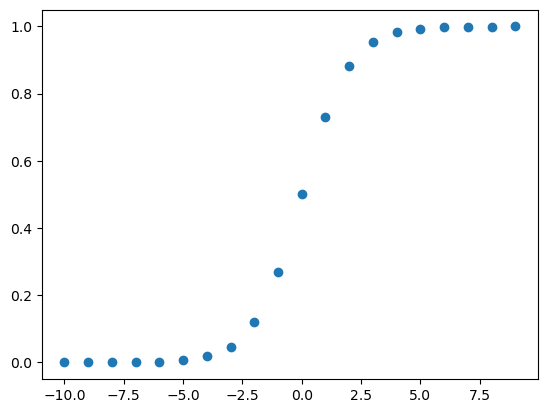

In [13]:
import math
def sigmoid(z):
    """
    시그모이드 함수: 임의의 실수 z를 0~1 사이로 변환
    σ(z) = 1 / (1 + e^(-z))
    """
    #### [ 빈칸: 이 부분을 완성하세요 — 시그모이드 수식 ]
    return 1 / (1 + math.exp(-z))

np.array(range(-10, 10)), [sigmoid(data) for data in np. array(range(-10, 10))]
import matplotlib.pylab as plt
plt.scatter(np.array(range(-10, 10)), [sigmoid(data) for data in np.array(range(-10, 10))])

### Step 5) 전체 흐름 한눈에 보기

> **이 코드가 하는 것:** 선형회귀(점수 예측)와 로지스틱 회귀(합격 판정)를
> 동일한 데이터로 나란히 출력해 전체 흐름을 확인합니다.

```python

In [14]:
print("\n" + "=" * 65)
print("=== Step 5: 선형회귀 + 로지스틱 회귀 전체 흐름 ===")
print("=" * 65)
print(f"  {'학생':^4} | {'예측점수(ŷ)':>10} | {'실제점수(y)':>10} | {'합격확률':>8} | {'최종판정':^10}")
print("  " + "-" * 58)

for i, name in enumerate(students):
    y_hat = linear_predict(study_hours[i], w=12, b=16)
    z     = logistic_score(study_hours[i], attendance_rate[i], w_study, w_att, bias)
    prob  = sigmoid(z)
    label = "합격 ✓" if prob >= 0.5 else "불합격 ✗"
    print(f"  학생 {name}  | {y_hat:>10} | {score_true[i]:>10} | {prob:>8.3f} | {label:^10}")

print("\n  [선형회귀]   → 공부 시간만 보고 점수(연속값) 예측")
print("  [로지스틱]   → 공부 시간 + 출석률 보고 합격 여부(0/1) 판정")
print("  [공통 구조]  → 둘 다 'z = wx + b' 에서 출발합니다")




=== Step 5: 선형회귀 + 로지스틱 회귀 전체 흐름 ===
   학생  |    예측점수(ŷ) |    실제점수(y) |     합격확률 |    최종판정   
  ----------------------------------------------------------
  학생 A  |         28 |         28 |    0.083 |   불합격 ✗   
  학생 B  |         52 |         52 |    0.886 |    합격 ✓   
  학생 C  |         76 |         74 |    0.998 |    합격 ✓   
  학생 D  |         40 |         39 |    0.438 |   불합격 ✗   

  [선형회귀]   → 공부 시간만 보고 점수(연속값) 예측
  [로지스틱]   → 공부 시간 + 출석률 보고 합격 여부(0/1) 판정
  [공통 구조]  → 둘 다 'z = wx + b' 에서 출발합니다


## [결과] 두 알고리즘 비교와 실무 적용

### 모델 비교표

| 구분 | 선형회귀 | 로지스틱 회귀 |
|---|---|---|
| **출력 형태** | 연속값 (예: 74점, 3.2억원) | 확률 → 클래스 (예: 합격/불합격) |
| **핵심 수식** | ŷ = wx + b | σ(wx + b) ≥ 0.5 → 클래스 1 |
| **오차 측정** | MSE (평균 제곱 오차) | Binary Cross-Entropy (이진 교차 엔트로피) |
| **주요 사용처** | 점수 예측, 집값, 매출 예측 | 스팸 분류, 이탈 예측, 합격/불합격 |
| **경계 유형** | 수치 범위 예측 | 결정 경계 (0.5 기준) |
| **핵심 약점** | 비선형 관계에 취약 | 복잡한 결정 경계 표현 불가 |

### 실무 선택 가이드

| 상황 | 추천 모델 | 이유 |
|---|---|---|
| 결과가 숫자 범위로 나와야 함 | **선형회귀** | 연속값 예측이 목적 |
| 결과가 "예/아니오" 형태 | **로지스틱 회귀** | 이진 분류의 기준선 모델 |
| 특성이 여러 개 | **다중 선형/로지스틱** | 구조는 같고 입력만 확장 |
| 더 복잡한 경계가 필요 | 의사결정트리, SVM, 신경망 | 로지스틱은 기준선으로 활용 |

### 한계점 정리

- **선형회귀:** 관계가 직선이 아닐 때 성능이 떨어집니다. 이상치에 민감합니다.
- **MSE:** 큰 오차를 강하게 벌주므로, 이상치가 있으면 점수가 급격히 나빠집니다.
- **선형회귀 확장:** 특성이 많아질수록 각 w의 의미 해석이 어려워지고, 단위가 다르면 가중치 크기를 직접 비교하기 어렵습니다.
- **로지스틱 회귀:** 단순 직선 경계만 표현 가능합니다. 복잡한 패턴에는 부족하지만 해석 가능한 기준선 모델로는 매우 유용합니다.

### 실무 적용 포인트

1. **연속값 예측 → 선형회귀부터 시작**, MSE로 기준 성능 확인
2. **여러 특성이 있으면 다중 선형회귀**로 확장, 각 w의 상대적 크기를 해석
3. **클래스 구분 문제 → 로지스틱 회귀로 기준선** 만든 뒤 다른 모델과 비교
4. **경계 근처 샘플(σ(z) ≈ 0.5)**은 판정이 불안정할 수 있으므로 추가 검토 필요

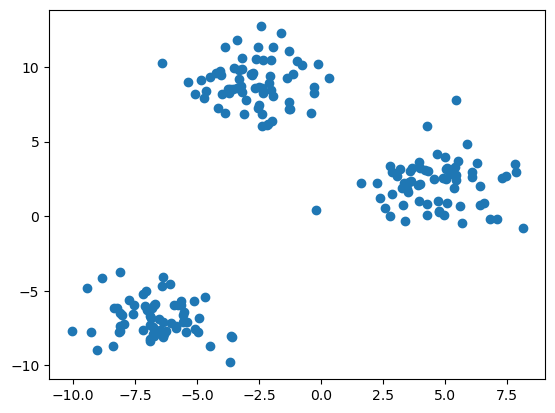

In [19]:
# 비지도 학습 알고리즘
    # 군집
        # k-평균은 반복 몇 번으로 데이터셋을 빠르고 효율적으로 클러스터로 묶을 수 있는 간단한 알고리즘
        # 로이드-포지 알고리즘
        # k-평균 알고리즘 훈련 : 각 클러스터의 중심을 찾고 가장 가까운 클러스터에 샘플을 할당
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
# 데이터 생성
X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)
# 시각화
plt.scatter(X[:,0], X[:,1])
plt.show()

    # 이상치 탐지

    # 밀도 추정

c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


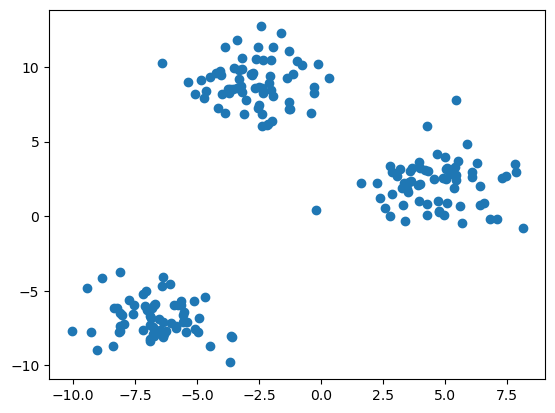

In [16]:
from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=5)
y_predict = kmeans.fit_predict(X)
# 시각화
plt.scatter(X[:,0], X[:, 1])
plt.show()

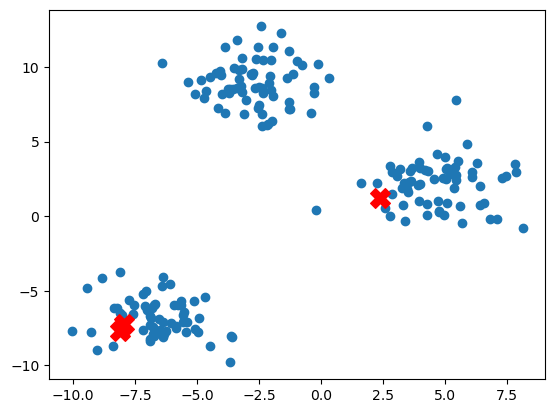

In [20]:
import numpy as np
# step 1 - 초기 중심 : 처음 중심을 랜덤으로 선택
k = 3
np.random.seed(42)
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]
plt.scatter(X[:,0], X[:,1])
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)
plt.show()


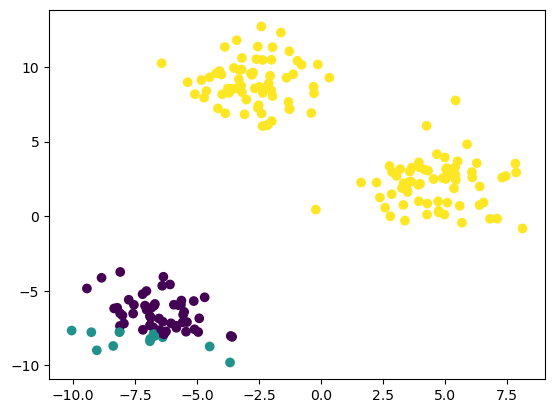

In [21]:
# step2 각 점을 가장 가까운 중심에 할당
# 거리계산 -> 가장 가까운 중심 선택
def assign_cluster(x, centroids):
    distance = np.linalg.norm(X[:,np.newaxis] - centroids, axis=2)
    return np.argmin(distance, axis=1)
label = assign_cluster(X, centroids)
label
# 각 점이 0, 1, 2중 하나로 배정됨
plt.scatter(X[:,0], X[:,1], c = label)
plt.show()

In [22]:
X[:, np.newaxis].shape, X.shape, centroids.shape
# 점 200개 * centroid 3개 * 좌표 2
# 첫 번쨰 점 [1,2]
# centroid : [3,4], [5,6], [7,8]
# [1-3, 2-4] [1-5, 2-6], [1-7, 2-8]
# 모든 centroid와의 좌표 계산
# 유클리드 거리(np.linalg.norm) (x차이**2 + y차이**2)(1/2) axis=2 좌표방향
# np.argmin(distance, axis=1) 가장 가까운 centroid 선택

((200, 1, 2), (200, 2), (3, 2))

In [23]:
X[:, np.newaxis].shape, X.shape, centroids.shape
# 점 200개 * centroid 3개 * 좌표 2
# 첫 번쨰 점 [1,2]
# centroid : [3,4], [5,6], [7,8]
# [1-3, 2-4] [1-5, 2-6], [1-7, 2-8]
# 모든 centroid와의 좌표 계산
# 유클리드 거리(np.linalg.norm) (x차이**2 + y차이**2)(1/2) axis=2 좌표방향
# np.argmin(distance, axis=1) 가장 가까운 centroid 선택

((200, 1, 2), (200, 2), (3, 2))

In [24]:
X[2], centroids[2]

(array([-6.89799735, -8.22599115]), array([2.36082389, 1.24681857]))

In [25]:
X[:,np.newaxis] - centroids

array([[[15.39583413,  9.88419939],
        [15.56166031, 10.40430022],
        [ 5.07771672,  1.43710049]],

       [[ 1.51847824, 17.44742021],
        [ 1.68430443, 17.96752104],
        [-8.79963917,  9.00032131]],

       [[ 1.05929617, -1.02571083],
        [ 1.22512236, -0.50561   ],
        [-9.25882124, -9.47280973]],

       ...,

       [[ 7.81691512, 17.36571854],
        [ 7.98274131, 17.88581938],
        [-2.50120229,  8.91861965]],

       [[11.88927456, 10.8068759 ],
        [12.05510075, 11.32697673],
        [ 1.57115715,  2.359777  ]],

       [[11.13514985, 10.35407691],
        [11.30097604, 10.87417774],
        [ 0.81703244,  1.90697801]]], shape=(200, 3, 2))

# [6교시]

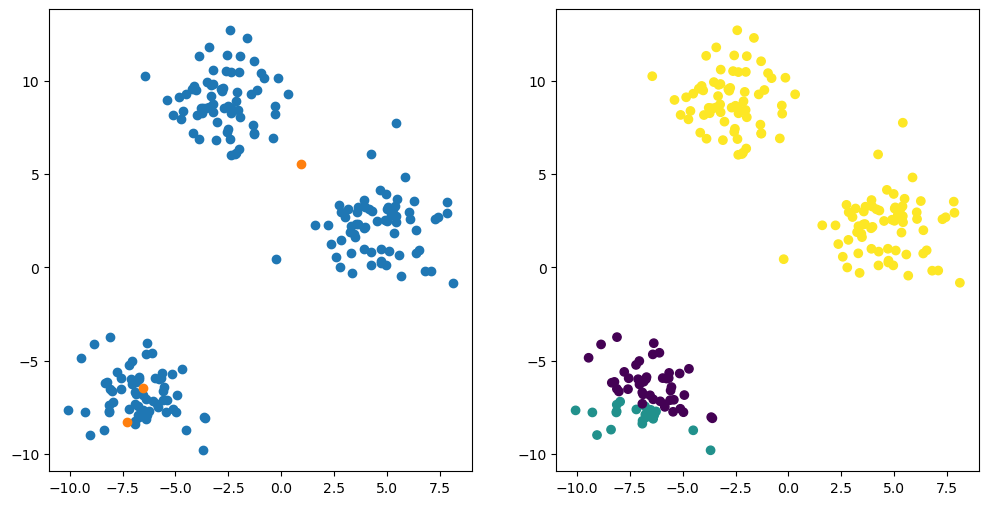

In [26]:
# 깅사님 코드
# step3 중심이동
# 각 그룹의 평균을 계산 --> 새로운 중심
# X[label == 0].mean(axis=0)
def update_centroid(X, label, k):
    return np.array(
        [ X[label==i].mean(axis=0) for i in range(k)]
        )

centroids = update_centroid(X, label, k)
centroids
# 1. 새로운 중심점을 좌표에 업데이트
# 2. 새로운 중심점을 기준으로 label을 분리해서 시각화

fig, ax = plt.subplots(1, 2, figsize = (12, 6))
ax[0].scatter(X[:,0], X[:,1])
ax[0].scatter(centroids[:,0], centroids[:,1])

labels = assign_cluster(X, centroids)
ax[1].scatter(X[:,0], X[:,1], c=labels)
plt.show()

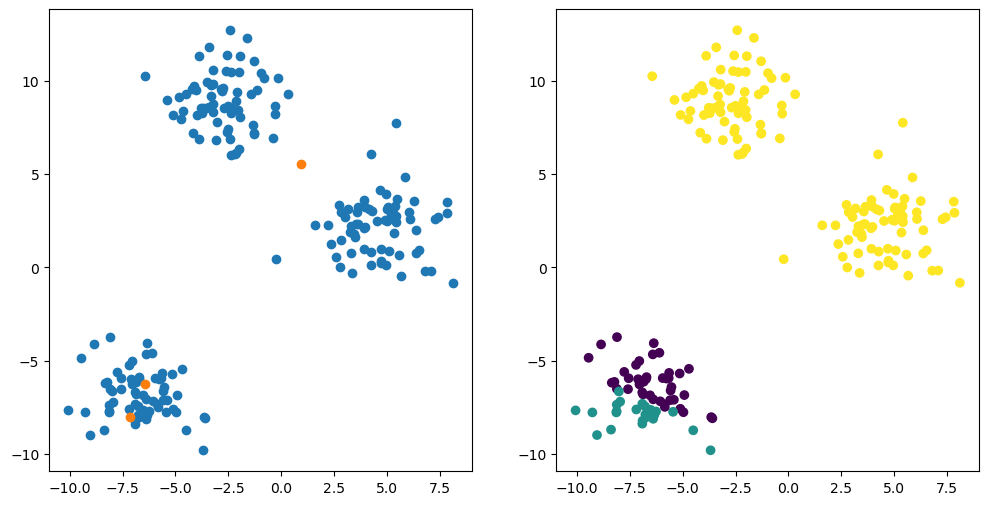

In [27]:
# 깅사님 코드
# step3 중심이동
# 각 그룹의 평균을 계산 --> 새로운 중심
# X[label == 0].mean(axis=0)
def update_centroid(X, labels, k):
    return np.array(
        [ X[labels==i].mean(axis=0) for i in range(k)]
        )

centroids = update_centroid(X, labels, k)
# 1. 새로운 중심점을 좌표에 업데이트
# 2. 새로운 중심점을 기준으로 label을 분리해서 시각화

fig, ax = plt.subplots(1, 2, figsize = (12, 6))
ax[0].scatter(X[:,0], X[:,1])
ax[0].scatter(centroids[:,0], centroids[:,1])

labels = assign_cluster(X, centroids)
ax[1].scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [28]:
# 데이터 준비
# 임의의 중심점 생성
# 중심점 주변의 데이터의 라벨을 설정
# 같은 라벨끼리 평균을 구해서 중심점 업데이트
# 새로운 중심점으로 라벨을 할당

# update_centroid
# assign_cluster


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# 데이터 생성
X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)

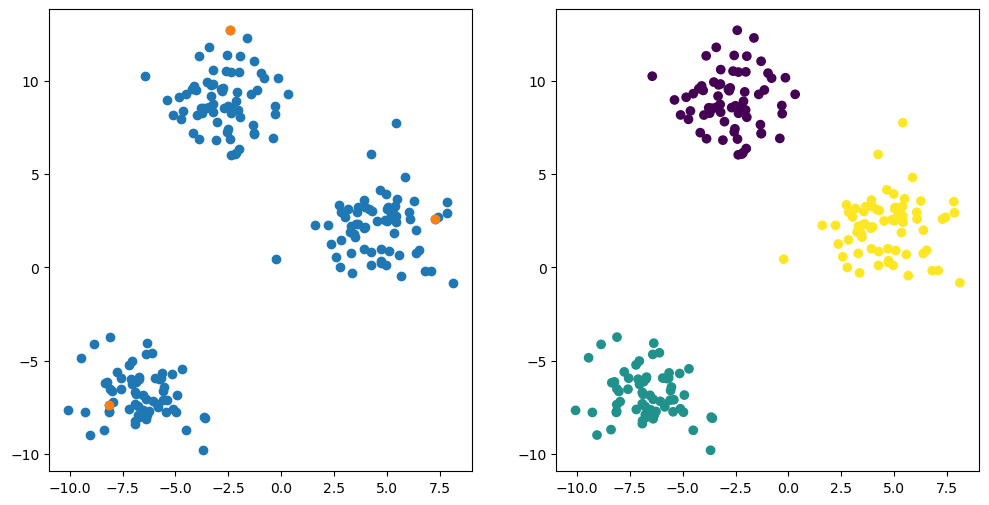

In [30]:
k = 3
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)  

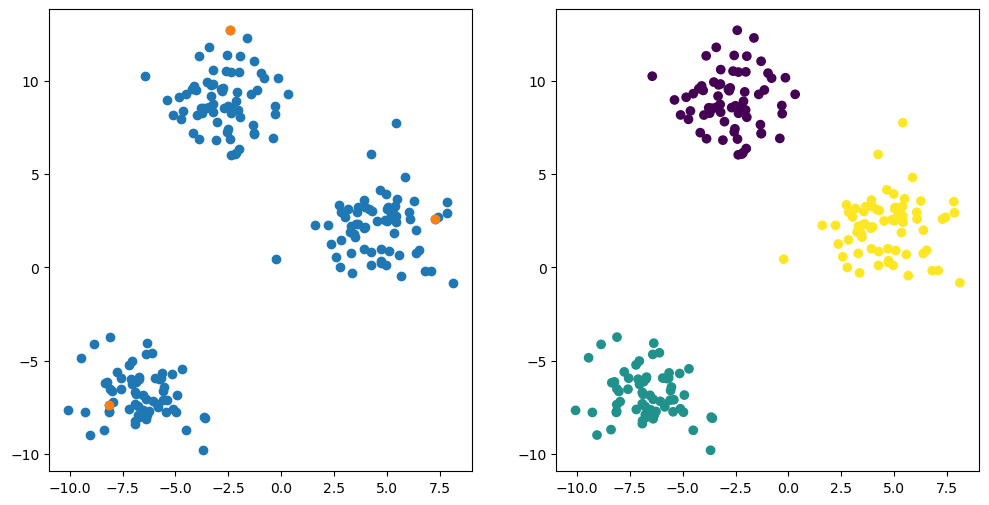

In [31]:
label = assign_cluster(X,centroids)
new_centroid = update_centroid(X,label,k)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)  
plt.show() 

centroids = new_centroid

c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

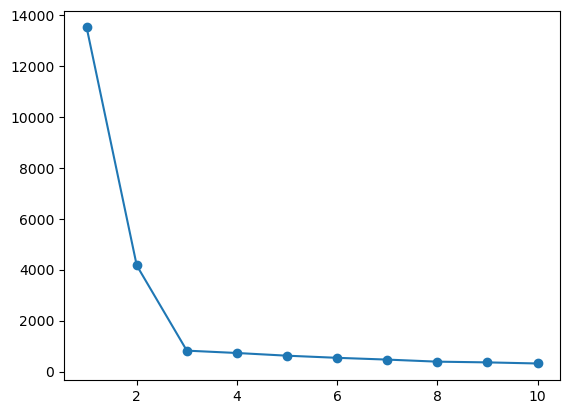

In [32]:
# 최적의 k 개수 찾기 - Elbow Method (기본)
# k가 증가할수록 오차는 감소 WCSS(Within-Cluster-Sum of Square) : 각 점과 중심점과의 거리의 제곱의 합
# 어느순간 감소폭이 급격히 줄어든다 ==> 그 지점
# 각 점과 중심점까지의 거리
k_range = range(1, 11)
wcss = []
for i in k_range :
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(k_range, wcss, '-o')
plt.show()

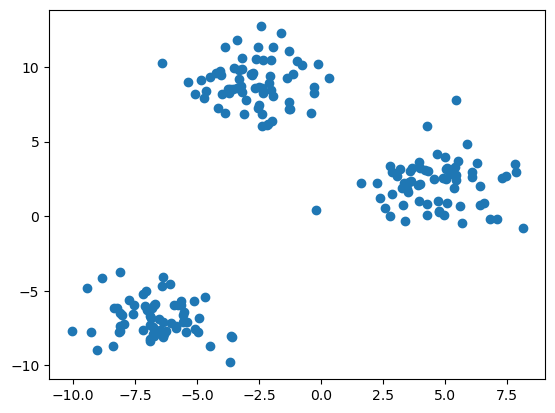

In [33]:
plt.scatter(X[:,0], X[:,1])

In [34]:
# 실루엣 score  
# 같은클러스터끼리는 가깝고 다른 클러스터와는 멀어야 좋다   -1 ~ 1
from sklearn.metrics import silhouette_score
scores = []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    lables = kmeans.fit_predict(X)
    score = silhouette_score(X,lables)
    scores.append(score)
np.argmax(scores)+2

c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

np.int64(3)

In [35]:
# 엘보우
# 실루엣
# 데이터시각화

# [8교시]

In [37]:
# 와인데이터 정답(품질)을 제거한 후 k-means로 클러스터를 분리..
from sklearn.datasets import load_wine

In [38]:
%pip install kagglehub
import kagglehub
# Download latest version
path = kagglehub.dataset_download("amisha0528/mall-customers-dataset")
from glob import glob
import pandas as pd
df = pd.read_csv(glob(path+'/*.*')[0])
df.head()  # 성별,나이,연간소득,지출점수

Note: you may need to restart the kernel to use updated packages.


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


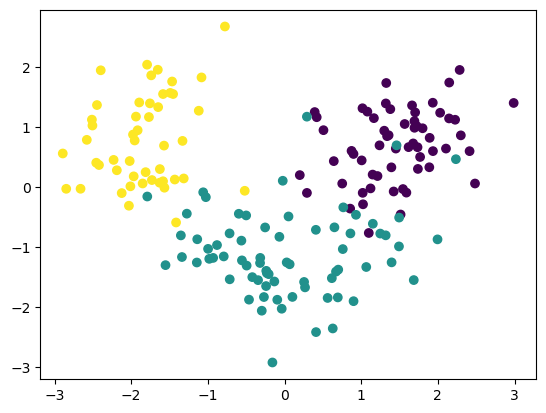

In [39]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
pipe = Pipeline([
    ('scaler', RobustScaler()),('pca', PCA(n_components=2))
])
X_preprocess = pipe.fit_transform(X)
plt.scatter(X_preprocess[:,0], X_preprocess[:,1], c=y)
plt.show()

c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\miniconda\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

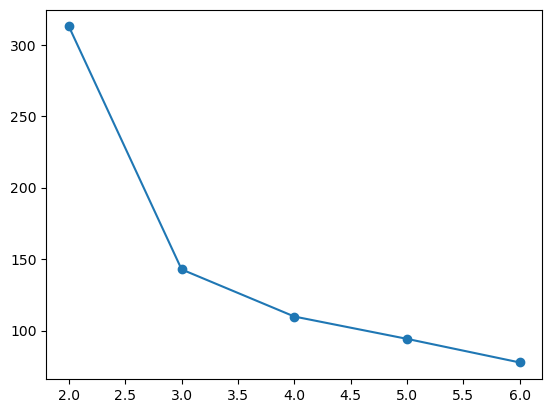

In [40]:
from sklearn.cluster import KMeans
k_range = range(2, 7)
ellbows = []
for k in k_range:
    model = KMeans (n_clusters=k, random_state=42)
    model.fit(X_preprocess)
    ellbows.append(model.inertia_)
plt.plot(k_range, ellbows, '-o')